In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
df = pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
   df[col] = le.fit_transform(df[col])

In [ ]:
df.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,0.512500,4.536667,1.005833,6.449417,1.740333,2.990383,1.014500,1.039167,5.445833,5.636667,5.565000,0.025833
std,2.021947,0.500052,2.029599,0.811181,1.442677,0.716660,0.576758,0.582185,0.808194,2.903290,2.859453,2.830627,0.158704
min,13.000000,0.000000,1.000000,0.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,0.000000,2.800000,0.000000,5.200000,1.100000,2.500000,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,1.000000,4.500000,1.000000,6.500000,1.800000,2.990000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,1.000000,6.300000,2.000000,7.600000,2.400000,3.480000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000
max,19.000000,1.000000,8.000000,2.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   int64  
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   int64  
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   int64  
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 122.0 KB


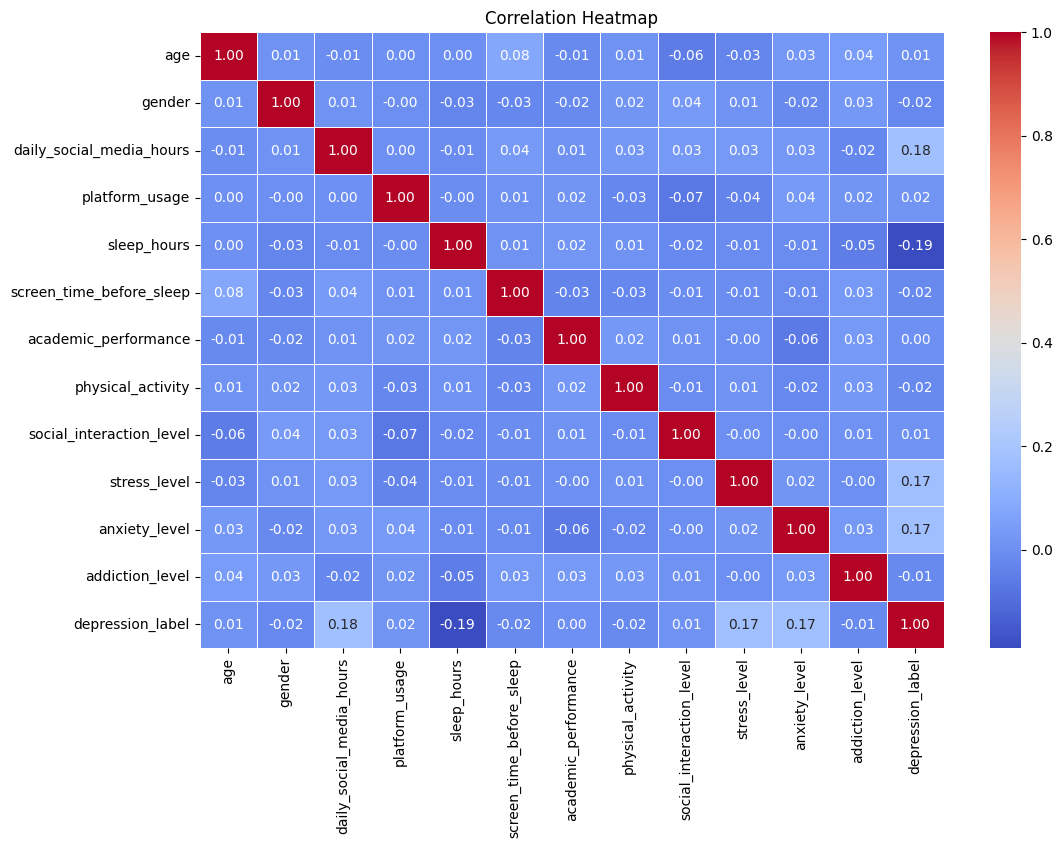

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",   # better color palette
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Logistic regression predicting the depression label

In [ ]:
x = df.drop('depression_label', axis =1)
y = df['depression_label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_train_pred = model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

Training Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       935
           1       0.93      0.56      0.70        25

    accuracy                           0.99       960
   macro avg       0.96      0.78      0.85       960
weighted avg       0.99      0.99      0.99       960



In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Test Accuracy", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy 0.9875
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240

